# Лабораторная работа №1: Разведочный анализ данных (EDA)

## 1. Описание набора данных

Для выполнения работы выбран датасет **Iris (Ирисы Фишера)**.

*   **Источник:** UCI Machine Learning Repository / Scikit-learn.
*   **Название:** Iris Plants Database.
*   **Краткое описание:** Датасет содержит информацию о геометрических параметрах цветов трех видов ирисов: *Iris setosa*, *Iris versicolor* и *Iris virginica*.
*   **Количество признаков:** 4 числовых признака + 1 целевой (вид).
*   **Цель анализа:** Изучить взаимосвязь между признаками и понять, какие из них лучше всего разделяют виды ирисов.

In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка датасета из Scikit-learn
from sklearn.datasets import load_iris

# Загружаем данные
iris = load_iris()

# Создаем DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Добавляем целевую переменную (вид ириса)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# 2. Основные характеристики
print("--- 2. Основные характеристики датасета ---\n")

# Первые 5 строк
print("Первые 5 строк датасета:")
print(df.head())

# Общая информация о данных
print("\nИнформация о данных (типы, пропуски):")
print(df.info())

# Статистическое описание
print("\nОписательная статистика:")
print(df.describe())

# Проверка на пропуски
print("\nКоличество пропусков в каждом столбце:")
print(df.isnull().sum())

# Количество объектов каждого класса
print("\nРаспределение целевой переменной (виды ирисов):")
print(df['species'].value_counts())

--- 2. Основные характеристики датасета ---

Первые 5 строк датасета:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Информация о данных (типы, пропуски):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    floa

--- 3. Визуальное исследование ---


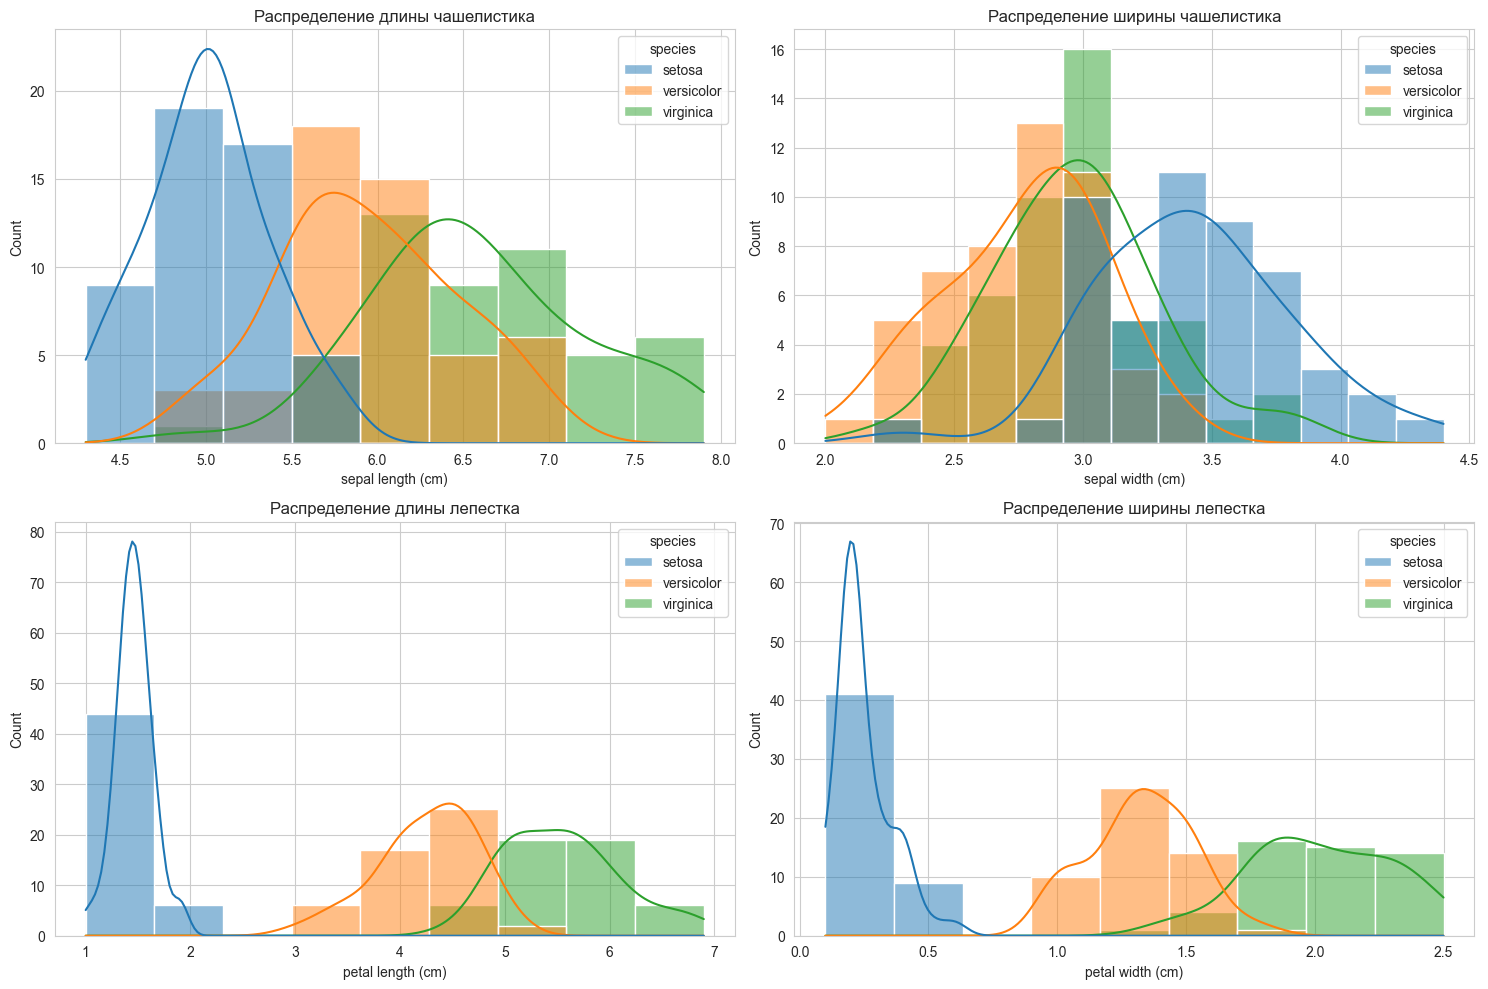

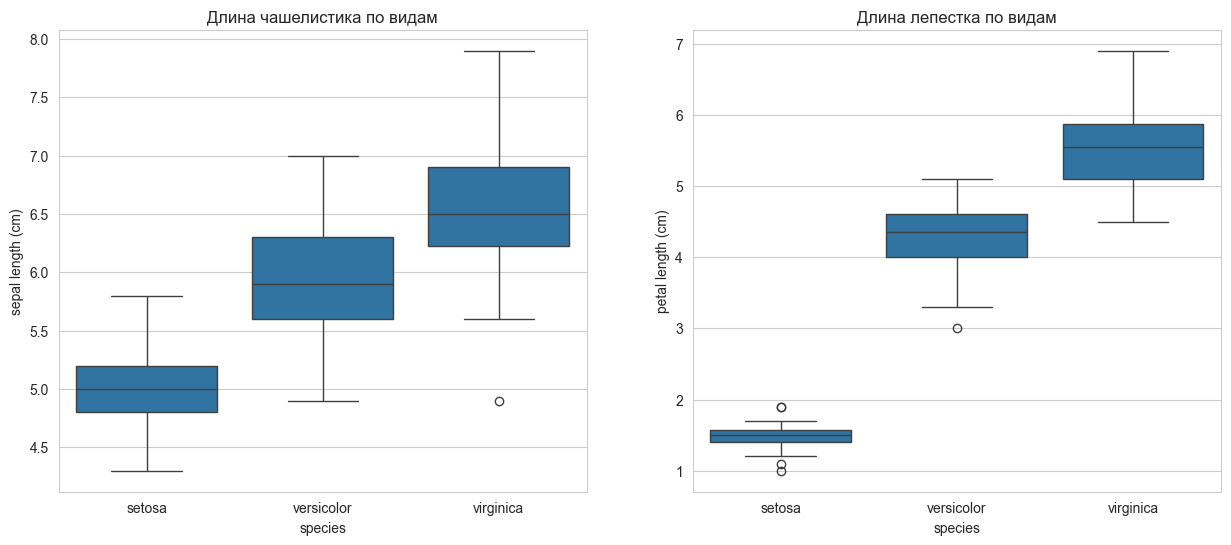

Попарные графики распределения признаков (может занять несколько секунд):


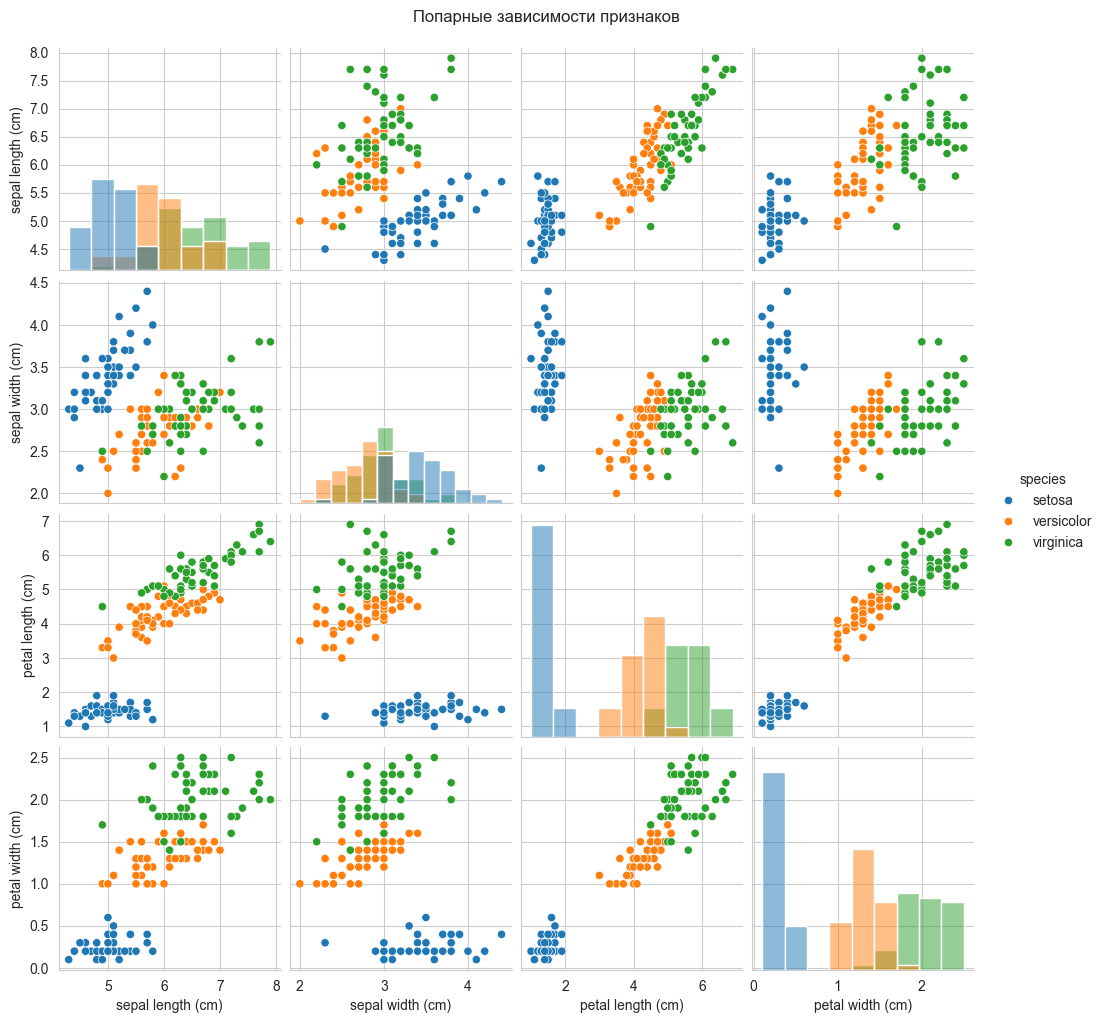

In [2]:
# 3. Визуальное исследование
print("--- 3. Визуальное исследование ---")

# Настройка стиля графиков
sns.set_style("whitegrid")
plt.figure(figsize=(15, 10))

# 3.1 Гистограммы распределения признаков
plt.subplot(2, 2, 1)
sns.histplot(data=df, x='sepal length (cm)', hue='species', kde=True)
plt.title('Распределение длины чашелистика')

plt.subplot(2, 2, 2)
sns.histplot(data=df, x='sepal width (cm)', hue='species', kde=True)
plt.title('Распределение ширины чашелистика')

plt.subplot(2, 2, 3)
sns.histplot(data=df, x='petal length (cm)', hue='species', kde=True)
plt.title('Распределение длины лепестка')

plt.subplot(2, 2, 4)
sns.histplot(data=df, x='petal width (cm)', hue='species', kde=True)
plt.title('Распределение ширины лепестка')

plt.tight_layout()
plt.show()

# 3.2 Ящики с усами (Box plots)
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='species', y='sepal length (cm)')
plt.title('Длина чашелистика по видам')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='species', y='petal length (cm)')
plt.title('Длина лепестка по видам')
plt.show()

# 3.3 Попарные графики (Pairplot)
print("Попарные графики распределения признаков (может занять несколько секунд):")
sns.pairplot(df, hue='species', diag_kind='hist')
plt.suptitle('Попарные зависимости признаков', y=1.02)
plt.show()

--- 4. Корреляция признаков ---
Матрица корреляции Пирсона:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


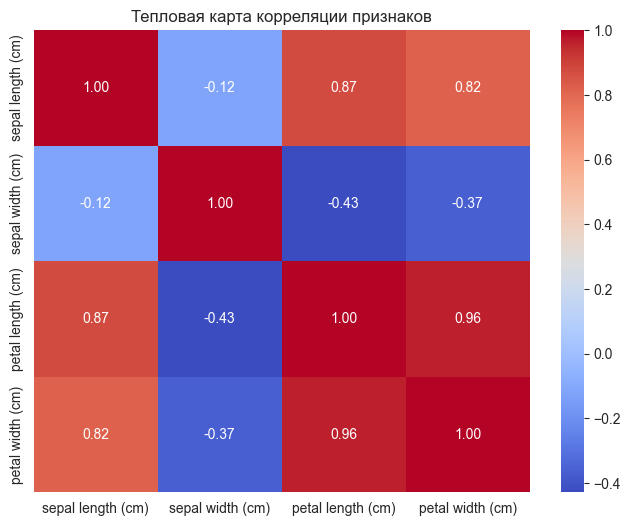


**Краткий анализ:**
- Наибольшая корреляция наблюдается между длиной и шириной лепестка (~0.96).
- Длина лепестка также сильно коррелирует с длиной чашелистика (~0.87).
- Ширина чашелистика слабо коррелирует с другими признаками.
- Высокая корреляция между признаками лепестка говорит о том, что эти признаки несут схожую информацию (мультиколлинеарность).


In [3]:
# 4. Корреляция признаков

# Создадим DataFrame только с числовыми признаками для расчета корреляции
df_numeric = df.drop('species', axis=1)

# Матрица корреляции Пирсона
correlation_matrix = df_numeric.corr()

print("--- 4. Корреляция признаков ---")
print("Матрица корреляции Пирсона:")
print(correlation_matrix)

# Визуализация матрицы корреляции (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            xticklabels=df_numeric.columns, yticklabels=df_numeric.columns)
plt.title('Тепловая карта корреляции признаков')
plt.show()

# Анализ корреляции
print("\n**Краткий анализ:**")
print("- Наибольшая корреляция наблюдается между длиной и шириной лепестка (~0.96).")
print("- Длина лепестка также сильно коррелирует с длиной чашелистика (~0.87).")
print("- Ширина чашелистика слабо коррелирует с другими признаками.")
print("- Высокая корреляция между признаками лепестка говорит о том, что эти признаки несут схожую информацию (мультиколлинеарность).")